In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

## 1. Carga y exploración de datos, archivo `dataset_ciberseguridad_sucio_500.csv` con pandas y mostramos las primeras filas para revisar la estructura del dataset.

In [2]:
df = pd.read_csv("dataset_ciberseguridad_sucio_500.csv")
df.head()

,id,failed_login_attempts,data_transfer_mb,connection_duration_sec,distinct_ip_accessed,request_frequency_per_min
0,1,12.0,713.82,147.4,43.0,200.30
1,2,0.0,37.14,1404.5,5.0,12.83
2,3,16.0,347.28,102.5,46.0,191.90
3,4,0.0,57.16,1556.5,3.0,9.68
4,5,1.0,43.9,1073.9,2.0,9.18


In [3]:
df.columns

Index(['id', ' failed_login_attempts ', 'data_transfer_mb',
       'connection_duration_sec', 'distinct_ip_accessed',
       'request_frequency_per_min'],
      dtype='str')

### Limpieza de nombres de columnas. La columna ` failed_login_attempts ` contiene espacios al inicio y al final. Usamos `.str.strip()` sobre el nombre de las columnas para eliminarlos.

In [4]:
df.columns = df.columns.str.strip()

In [5]:
df.columns

Index(['id', 'failed_login_attempts', 'data_transfer_mb',
       'connection_duration_sec', 'distinct_ip_accessed',
       'request_frequency_per_min'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         510 non-null    int64  
 1   failed_login_attempts      508 non-null    float64
 2   data_transfer_mb           505 non-null    str    
 3   connection_duration_sec    502 non-null    str    
 4   distinct_ip_accessed       503 non-null    float64
 5   request_frequency_per_min  507 non-null    float64
dtypes: float64(3), int64(1), str(2)
memory usage: 24.0 KB


In [7]:
df.describe()

,id,failed_login_attempts,distinct_ip_accessed,request_frequency_per_min
count,510.000000,508.000000,503.000000,507.000000
mean,255.500000,1.805118,11.956262,2021.587811
std,147.368586,44.920480,16.669092,44409.389694
min,1.000000,-999.000000,1.000000,1.000000
25%,128.250000,0.000000,2.000000,9.265000
50%,255.500000,1.000000,4.000000,12.130000
75%,382.750000,3.000000,8.000000,21.820000
max,510.000000,30.000000,58.000000,999999.000000


## 2. Limpieza de datos.

In [8]:
df.isnull().sum()

id                           0
failed_login_attempts        2
data_transfer_mb             5
connection_duration_sec      8
distinct_ip_accessed         7
request_frequency_per_min    3
dtype: int64

In [9]:
df["data_transfer_mb"] = pd.to_numeric(
    df["data_transfer_mb"], 
    errors="coerce"
)

df["connection_duration_sec"] = pd.to_numeric(
    df["connection_duration_sec"], 
    errors="coerce"
)

### Tratamiento de valores atípicos. Detectamos dos marcadores de dato erróneo:- Intentos de conexión negativos (`-999`) en `failed_login_attempts`.- Frecuencia de peticiones elevadísima (`999999`) en `request_frequency_per_min`.Ambos se convierten en `NaN` para tratarlos como valores faltantes.

In [10]:
df.loc[df["failed_login_attempts"] < 0, "failed_login_attempts"] = np.nan

In [11]:
df.loc[df["request_frequency_per_min"] == 999999, "request_frequency_per_min"] = np.nan

In [12]:
df.isnull().sum()

id                            0
failed_login_attempts         3
data_transfer_mb             35
connection_duration_sec      28
distinct_ip_accessed          7
request_frequency_per_min     4
dtype: int64

## Rellenamos los valores faltantes de las columnas numéricas usando la **mediana**

In [13]:
columnas = [
    "failed_login_attempts",
    "data_transfer_mb",
    "connection_duration_sec",
    "distinct_ip_accessed",
    "request_frequency_per_min"
]

for columna in columnas:
    df[columna] = df[columna].fillna(df[columna].median())

In [14]:
df.isnull().sum()

id                           0
failed_login_attempts        0
data_transfer_mb             0
connection_duration_sec      0
distinct_ip_accessed         0
request_frequency_per_min    0
dtype: int64

Comprobamos que ya no quedan nulos y que todas las columnas numéricas tienen tipo numérico.

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         510 non-null    int64  
 1   failed_login_attempts      510 non-null    float64
 2   data_transfer_mb           510 non-null    float64
 3   connection_duration_sec    510 non-null    float64
 4   distinct_ip_accessed       510 non-null    float64
 5   request_frequency_per_min  510 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 24.0 KB


In [16]:
df.describe()

,id,failed_login_attempts,data_transfer_mb,connection_duration_sec,distinct_ip_accessed,request_frequency_per_min
count,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000
mean,255.500000,3.762745,233.597824,1698.787843,11.847059,49.008784
std,147.368586,6.187365,283.963669,1571.063147,16.579988,75.505798
min,1.000000,0.000000,1.000000,-500.000000,1.000000,1.000000
25%,128.250000,0.000000,36.450000,899.750000,2.000000,9.290000
50%,255.500000,1.000000,55.740000,1246.950000,4.000000,12.115000
75%,382.750000,3.000000,391.640000,1632.825000,8.000000,21.527500
max,510.000000,30.000000,1082.880000,6794.700000,58.000000,272.300000


### Corrección de duración de conexión negativa Al revisar las estadísticas vemos que `connection_duration_sec` tiene un mínimo de `-500`, lo cual no tiene sentido. Marcamos los valores negativos como `NaN` y los rellenamos con la mediana de la columna.

In [17]:
df.loc[df["connection_duration_sec"] < 0, "connection_duration_sec"] = np.nan

In [18]:
df["connection_duration_sec"] = df["connection_duration_sec"].fillna(
    df["connection_duration_sec"].median()
)

In [19]:
df["connection_duration_sec"].min()

np.float64(59.4)

## 3. Preparación para el clustering

In [20]:
columnas = [
    "failed_login_attempts",
    "data_transfer_mb",
    "connection_duration_sec",
    "distinct_ip_accessed",
    "request_frequency_per_min"
]

X = df[columnas]

### Método del Codo . Probamos K-Means con `k` desde 2 hasta 10 y guardamos la **inercia** de cada modelo (suma de distancias al cuadrado de cada punto a su centroide).

In [21]:
inercia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercia.append(kmeans.inertia_)

c:\Users\Leotacotroid18\anaconda3\envs\ia\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Leotacotroid18\anaconda3\envs\ia\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Leotacotroid18\anaconda3\envs\ia\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Leotacotroid18\anaconda3\envs\ia\Lib\site-packages\sklearn\cluster\_kmeans.p

Graficamos la inercia frente al número de clústeres para identificar el "codo" y elegir el valor de `k` adecuado.

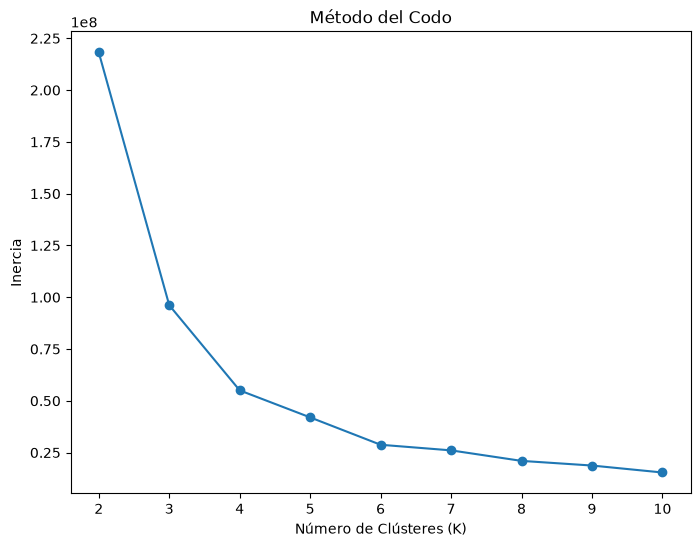

In [22]:
plt.figure(figsize=(8,6))

plt.plot(range(2, 11), inercia, marker="o")

plt.title("Método del Codo")
plt.xlabel("Número de Clústeres (K)")
plt.ylabel("Inercia")

plt.show()

## 4. Ajuste del modelo K-Means con 4 clústeres. Según el método del codo elegimos `k = 4`.

In [23]:
kmeans = KMeans(n_clusters=4, random_state=42)

kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

df["cluster"] = labels

c:\Users\Leotacotroid18\anaconda3\envs\ia\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Observamos cuántos registros cayeron en cada clúster.

In [24]:
df["cluster"].value_counts()

cluster
2    311
0     98
1     65
3     36
Name: count, dtype: int64

### Perfil de los clústeres Calculamos la media de cada característica por clúster para interpretar qué representa cada grupo (p. ej., comportamiento de ataque vs. comportamiento normal).

In [25]:
df.groupby("cluster")[[
    "failed_login_attempts",
    "data_transfer_mb",
    "connection_duration_sec",
    "distinct_ip_accessed",
    "request_frequency_per_min"
]].mean()

,failed_login_attempts,data_transfer_mb,connection_duration_sec,distinct_ip_accessed,request_frequency_per_min
cluster,,,,,
0,15.214286,699.775714,158.954082,43.357143,194.899541
1,0.815385,322.192462,5119.253846,5.553846,17.688615
2,1.086817,56.399389,1240.150000,3.877814,13.069405
3,1.027778,335.393056,3725.363889,6.277778,18.888333


## 5. Visualización de los clústeres

In [26]:
centroids = kmeans.cluster_centers_

Graficamos los puntos de cada clúster junto con los centroides para cada par de características.

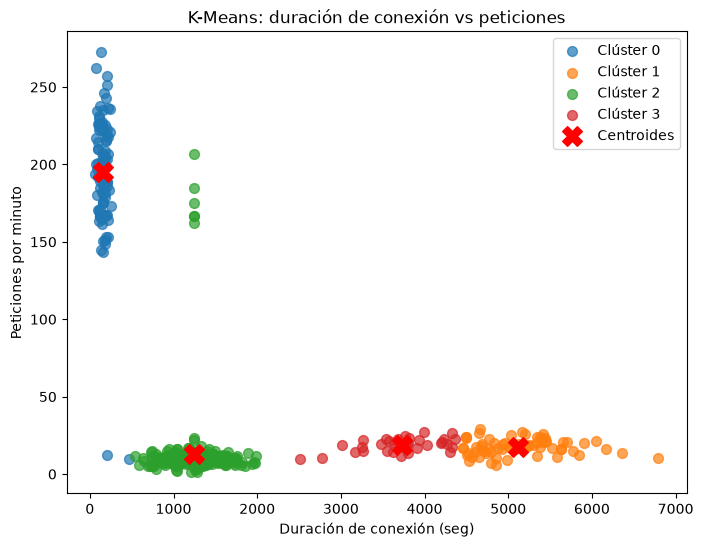

In [27]:
indice = {
    "failed_login_attempts": 0,
    "data_transfer_mb": 1,
    "connection_duration_sec": 2,
    "distinct_ip_accessed": 3,
    "request_frequency_per_min": 4
}

colores = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

def graficar_clusters(x_col, y_col, titulo, xlabel, ylabel):
    plt.figure(figsize=(8, 6))
    for cluster_id in sorted(df["cluster"].unique()):
        grupo = df[df["cluster"] == cluster_id]
        plt.scatter(
            grupo[x_col],
            grupo[y_col],
            color=colores[cluster_id],
            s=50,
            alpha=0.7,
            label=f"Clúster {cluster_id}"
        )
    plt.scatter(
        centroids[:, indice[x_col]],
        centroids[:, indice[y_col]],
        color="red",
        marker="X",
        s=200,
        label="Centroides"
    )
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()



graficar_clusters(
    "connection_duration_sec",
    "request_frequency_per_min",
    "K-Means: duración de conexión vs peticiones",
    "Duración de conexión (seg)",
    "Peticiones por minuto"
)


## 6. Resumen del clustering

In [28]:
df.groupby("cluster").mean()

,id,failed_login_attempts,data_transfer_mb,connection_duration_sec,distinct_ip_accessed,request_frequency_per_min
cluster,,,,,,
0,248.091837,15.214286,699.775714,158.954082,43.357143,194.899541
1,285.076923,0.815385,322.192462,5119.253846,5.553846,17.688615
2,257.549839,1.086817,56.399389,1240.150000,3.877814,13.069405
3,204.555556,1.027778,335.393056,3725.363889,6.277778,18.888333
